In [3]:
# Load the CSV into a dataframe
import pandas as pd

file_path = './games_of_all_time_cleaned.csv'
df_games = pd.read_csv(file_path, encoding='utf-8')

print(df_games.head())
print(df_games.shape)

                              game_name  meta_score  user_score  \
0  The Legend of Zelda: Ocarina of Time        99.0        91.0   
1                    Super Mario Galaxy        97.0        91.0   
2                  Super Mario Galaxy 2        97.0        91.0   
3                         Metroid Prime        97.0        89.0   
4                   Super Mario Odyssey        97.0        89.0   

          platform                                        description  \
0  ['nintendo-64']  As a young boy, Link is tricked by Ganondorf, ...   
1          ['wii']  [Metacritic's 2007 Wii Game of the Year] The u...   
2          ['wii']  Super Mario Galaxy 2, the sequel to the galaxy...   
3     ['gamecube']  Samus returns in a new mission to unravel the ...   
4       ['switch']  New Evolution of Mario Sandbox-Style Gameplay....   

                                                 url           developer  \
0  https://www.metacritic.com/game/nintendo-64/th...            Nintendo   
1  htt

In [4]:
# Quick missingness + basic cleaning plan:
# - Standardize text columns (strip whitespace, empty strings -> NA)
# - Ensure meta_score and user_score are numeric
# - Impute missing scores with median (robust)
# - Normalize both scores to [0, 1] using min-max on the cleaned/imputed columns

import numpy as np
import pandas as pd

# Work on a copy so original stays intact
clean_games = df_games.copy()

# Normalize obvious text fields: strip and convert empty to NA
text_cols = ['game_name', 'platform', 'description', 'url', 'developer', 'genre', 'type', 'rating']
for col in text_cols:
    if col in clean_games.columns:
        clean_games[col] = clean_games[col].astype('string')
        clean_games[col] = clean_games[col].str.strip()
        clean_games[col] = clean_games[col].replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})

# Coerce scores to numeric
for score_col in ['meta_score', 'user_score']:
    if score_col in clean_games.columns:
        clean_games[score_col] = pd.to_numeric(clean_games[score_col], errors='coerce')

# Missingness report
missing_counts = clean_games.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(clean_games)).round(4)
missing_report = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})

print(missing_report.head(12))

# Impute missing scores with median
meta_median = float(clean_games['meta_score'].median(skipna=True))
user_median = float(clean_games['user_score'].median(skipna=True))

meta_missing_before = int(clean_games['meta_score'].isna().sum())
user_missing_before = int(clean_games['user_score'].isna().sum())

clean_games['meta_score'] = clean_games['meta_score'].fillna(meta_median)
clean_games['user_score'] = clean_games['user_score'].fillna(user_median)

meta_missing_after = int(clean_games['meta_score'].isna().sum())
user_missing_after = int(clean_games['user_score'].isna().sum())

print(meta_median)
print(user_median)
print(meta_missing_before)
print(meta_missing_after)
print(user_missing_before)
print(user_missing_after)

# Min-max normalize to [0, 1]
meta_min = float(clean_games['meta_score'].min())
meta_max = float(clean_games['meta_score'].max())
user_min = float(clean_games['user_score'].min())
user_max = float(clean_games['user_score'].max())

clean_games['meta_score_norm_0_1'] = (clean_games['meta_score'] - meta_min) / (meta_max - meta_min) if meta_max > meta_min else 0.0
clean_games['user_score_norm_0_1'] = (clean_games['user_score'] - user_min) / (user_max - user_min) if user_max > user_min else 0.0

# Basic sanity checks
print(clean_games[['meta_score', 'meta_score_norm_0_1', 'user_score', 'user_score_norm_0_1']].describe())
print(clean_games.head())

             missing_count  missing_pct
game_name                0          0.0
meta_score               0          0.0
user_score               0          0.0
platform                 0          0.0
description              0          0.0
url                      0          0.0
developer                0          0.0
genre                    0          0.0
type                     0          0.0
rating                   0          0.0
73.0
72.8
0
0
0
0
        meta_score  meta_score_norm_0_1   user_score  user_score_norm_0_1
count  8831.000000          8831.000000  8831.000000          8831.000000
mean     70.876621             0.680416    69.903918             0.707332
std      12.181944             0.138431    13.161456             0.137099
min      11.000000             0.000000     2.000000             0.000000
25%      63.000000             0.590909    63.000000             0.635417
50%      73.000000             0.704545    72.800000             0.737500
75%      80.000000      

                column   min     median       mean   max  missing
0           meta_score  11.0  73.000000  70.876621  99.0        0
1           user_score   2.0  72.800000  69.903918  98.0        0
2  meta_score_norm_0_1   0.0   0.704545   0.680416   1.0        0
3  user_score_norm_0_1   0.0   0.737500   0.707332   1.0        0
./games_of_all_time_cleaned_normalized.csv


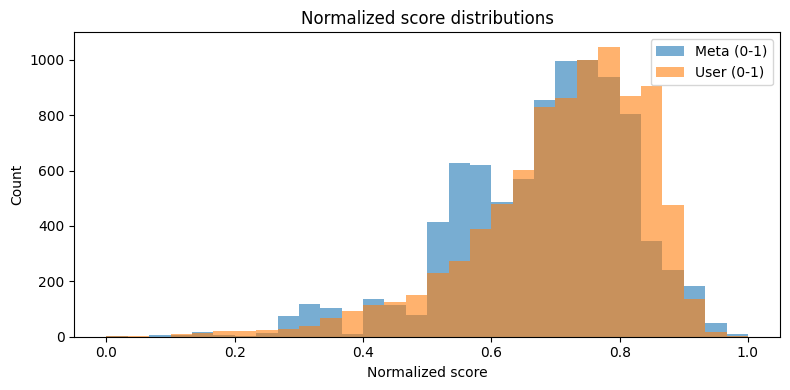

In [5]:
# Save cleaned dataset to disk and generate a small, readable summary table for the user
import pandas as pd

out_path = './games_of_all_time_cleaned_normalized.csv'
clean_games.to_csv(out_path, index=False, encoding='utf-8')

summary_rows = []
for col in ['meta_score', 'user_score', 'meta_score_norm_0_1', 'user_score_norm_0_1']:
    series_vals = clean_games[col]
    summary_rows.append({
        'column': col,
        'min': float(series_vals.min()),
        'median': float(series_vals.median()),
        'mean': float(series_vals.mean()),
        'max': float(series_vals.max()),
        'missing': int(series_vals.isna().sum())
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)
print(out_path)

# Quick distribution check for normalized scores
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(clean_games['meta_score_norm_0_1'], bins=30, alpha=0.6, label='Meta (0-1)')
plt.hist(clean_games['user_score_norm_0_1'], bins=30, alpha=0.6, label='User (0-1)')
plt.legend()
plt.title('Normalized score distributions')
plt.xlabel('Normalized score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

What I did to clean it
I loaded games_of_all_time_cleaned.csv (8,831 rows × 10 columns) and ran a basic cleaning pass:

1) Standardized text fields

Trimmed whitespace on game_name, platform, description, url, developer, genre, type, rating
Converted empty strings / "" / "None" to actual missing values (NA)
2) Handled missing values

Coerced meta_score and user_score to numeric (errors='coerce').
In this file, there were no missing values in any column after parsing (so no imputation was actually needed).
3) Normalized meta and user scores

Created two new columns using min-max scaling to [0, 1]:
meta_score_norm_0_1
user_score_norm_0_1
This keeps rank/order intact and makes the two score types directly comparable on the same scale.

Quick results summary (after cleaning)
Your score ranges look like this:

meta_score: min 11, median 73.0, mean 70.88, max 99
user_score: min 2, median 72.8, mean 69.90, max 98
Normalized columns are bounded to 0–1 (as expected), with 0 missing.
Output file (ready to download)
I saved the cleaned + normalized dataset here:

games_of_all_time_cleaned_normalized.csv

If you want, I can also:

parse platform and genre from stringified lists into real Python lists (or explode them into one-row-per-platform / one-row-per-genre for analysis),
standardize type / rating categories,
add a combined score (e.g., weighted meta+user) after normalization.